In [41]:
from utils import goto_project_root
from utils.path_settings import MODEL_SAVE_PATH, DATA_PATH, LOG_PATH, CONFIG_PATH
from torch.utils.tensorboard import SummaryWriter
import SimulateDatasets.GenTrainingData as g
from utils import create_splits, get_dataloaders, force_remove_dir
from Network_models import Trainer as t
from importlib import reload
import os
reload(t)
reload(g)
import time
import torch
import numpy as np
from pytorch3d.transforms import so3_relative_angle
from pytorch3d.transforms import quaternion_to_matrix
import json

In [6]:
os.getcwd()

'C:\\Users\\timmy\\Documents\\Projects_dir\\Mental_Rotations\\mental-rotations'

In [42]:
cell_type = "RNN"
seq_len = 100
prep_phase = 50
configs = {

    "training_config": {
        "task_id": "1.1",
        "batch_size": 128,
        "mini_batch_size": 32,
        "seq_len": seq_len,
        "prep_phase": prep_phase,
        "object_path": os.getcwd() + "\\data\\cow_mesh\\cow.obj",
    }
}

configs["training_config"]["data_save_path"] = DATA_PATH + ("\\Data_" + configs["training_config"]["task_id"] + "_" + 
                                                            configs["model_id"]+ ".pth")
configs["save_path"] = configs["save_path"] + ("_" + configs["training_config"]["task_id"] + "_" + configs["model_id"])
configs["check_path"] = configs["check_path"] + ("_" + configs["training_config"]["task_id"] + "_" + configs["model_id"])
configs["log_path"] = configs["log_path"] + ("\\Log_" + configs["training_config"]["task_id"] + "_" + configs["model_id"])
if configs["distance_loss"][-7:] == "gradual":
    configs["save_path"] = configs["save_path"] + "_gradual"
    configs["check_path"] = configs["check_path"] + "_gradual"
    configs["log_path"] = configs["log_path"] + "_gradual"
    configs["model_specs"]["model_params"]["stepwise"] = True
else:
    configs["model_specs"]["model_params"]["stepwise"] = False

for path in [configs["save_path"], configs["check_path"], configs["log_path"]]:
    os.makedirs(path, exist_ok=True)
    
data1 = g.gen_training_data(configs['training_config'])
dataloaders = get_dataloaders(data1, batch_size=configs["training_config"]["mini_batch_size"], k=5)

An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "C:\Users\timmy\anaconda3\envs\mental-rotations\lib\site-packages\iopath\common\event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


In [35]:
configs['training_config']['data_save_path']

'D:\\Projects\\mental-rotations\\data\\Data_1.1_lean.pth'

In [23]:
# DON"T RUN THIS IF YOU ARE NOT TRAINING A NEW MODEL. UNCOMMENT TO TRAIN
reload(t)
# for i, (train_loader, test_loader) in enumerate(dataloaders):
#     # remove log directories: 
#     new_log_path = configs['log_path'] + f"\\{cell_type}_model_{configs['training_config']['task_id']}_{i+1}"
#     force_remove_dir(new_log_path)
rnn_trainer = t.Trainer(configs)
for i, (train_loader, test_loader) in enumerate(dataloaders):
    print(f"Training on split {i+1}")
    if i:
        rnn_trainer.refresh()
    new_log_path = configs['log_path'] + f"\\{cell_type}_model_{configs['training_config']['task_id']}_{i+1}"
    new_check_path = configs['check_path'] + f"\\model_{i+1}"

    os.makedirs(new_check_path, exist_ok=True)
    old_log_path = configs["log_path"]
    old_save_path = configs["save_path"]
    old_check_path = configs["check_path"]
    configs["log_path"] = new_log_path
    configs["save_path"] = old_save_path + f"\\model_{i+1}"
    configs["full_model_path"] = old_save_path + f"\\model_{i+1}.pth"
    configs["check_path"] = new_check_path

    with (open(CONFIG_PATH + f"\\{cell_type}_model_{configs['training_config']['task_id']}_{configs['model_id']}_{i+1}"
                             f".json", "w")as f):
        json.dump(configs, f, indent=4)

    configs["log_path"] = old_log_path
    configs["save_path"] = old_save_path
    configs.pop("full_model_path")
    configs["check_path"] = old_check_path
    # 
    # rnn_trainer.train(train_loader, 
    #                   test_loader, 
    #                   epochs=100, 
    #                   save_path = configs["save_path"] + f"\\model_{i+1}.pth", 
    #                   check_path= new_check_path, 
    #                   log_path = new_log_path)
    # 
    # rnn_trainer.save_model(configs["save_path"] + f"\\model_{i+1}.pth", full = 1)

Training on split 1
Training on split 2
Training on split 3
Training on split 4
Training on split 5


In [7]:
rnn_trainer.load_model(configs["save_path"] + f"\\model_4.pth", full = 1)

In [8]:
rnn_trainer.model.eval()
# Let's print an average of geodesic distances between network output and target, for a batch of 1000 random quaternions 
# where all parts are positive. 
num = 1
features = torch.zeros(num, seq_len, 8).to("cuda")
target = torch.zeros(num, 4).to("cuda")
for i in range(num):
    target[i] = torch.rand(4).to("cuda")
    target[i] = target[i]/torch.norm(target[i])
    for j in range(prep_phase):
        features[i, j, :] = torch.cat([target[i], -target[i]])

rnn_trainer.model(features)
pred = rnn_trainer.model.pred
g_loss = rnn_trainer.distance_loss(pred, target)
print(f"Average geodesic distance: {g_loss.mean()}")

Average geodesic distance: 153.92401123046875


In [6]:
features.dtype

torch.float32

In [10]:
from sklearn.manifold import TSNE

In [11]:
# Let's now try to access the hidden unit activities
model = rnn_trainer.model
def get_hidden_state(module, input, output):
    global hidden_states
    hidden_states.append(output[0].detach().clone())

model.rnn.register_forward_hook(get_hidden_state)
hidden_states = []
out = model(features)
activations = hidden_states[0][0:, :] # Get the single tensor from the list
activations = activations.view(-1, activations.shape[-1])  # Flatten to (batch_size * seq_len, hidden_unit_num)

# t-SNE for 3D visualization
tsne = TSNE(n_components=3, random_state=0)
tsne_results = tsne.fit_transform(activations.cpu().detach().numpy())

# Add Metadata for TensorBoard Visualization
metadata = []
for i in range(seq_len):
    metadata.extend([f"Timestep {i}"] * 1)
metadata = np.array(metadata, dtype=object)

# Create TensorBoard Writer (Outside Training Loop)
writer = SummaryWriter()

# Log to TensorBoard as 3D scatter plot with metadata
writer.add_embedding(tsne_results, metadata=metadata, tag="hidden_state_trajectories")
writer.close()

activations = activations.cpu().detach().numpy()

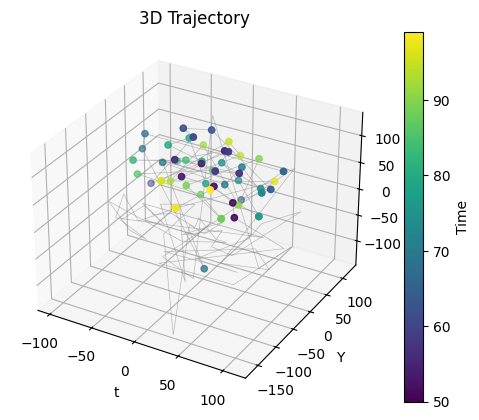

In [45]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
time = np.arange(seq_len)
# Plot the trajectory
ax.scatter(tsne_results[50:, 0], tsne_results[50:, 1], tsne_results[50:, 2], c=time[50:], cmap='viridis')
ax.plot(tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2], c='gray', alpha=0.5, linewidth=0.5)
# colorbar
cbar = plt.colorbar(ax.scatter(tsne_results[50:, 0], tsne_results[50:, 1], tsne_results[50:, 2], c=time[50:], cmap='viridis'))
cbar.set_label('Time')
# Customize the plot (optional)
ax.set_xlabel('t')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Trajectory')

plt.show()

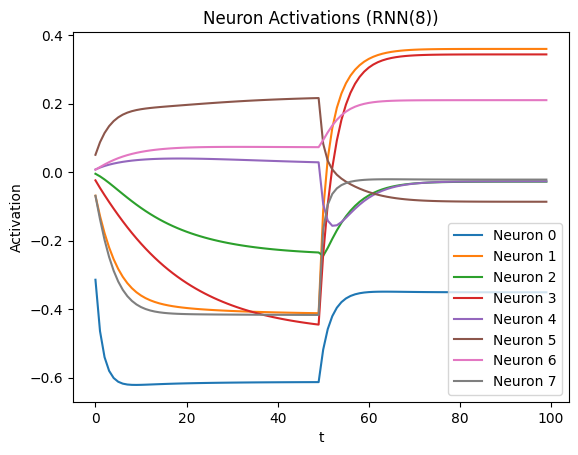

In [46]:
fig, ax = plt.subplots()
for neuron in range(8):
    ax.plot(time, activations[:, neuron], label=f"Neuron {neuron}")
ax.legend()
ax.set_xlabel('t')
ax.set_ylabel('Activation')
ax.set_title('Neuron Activations (RNN(8))')
plt.show()

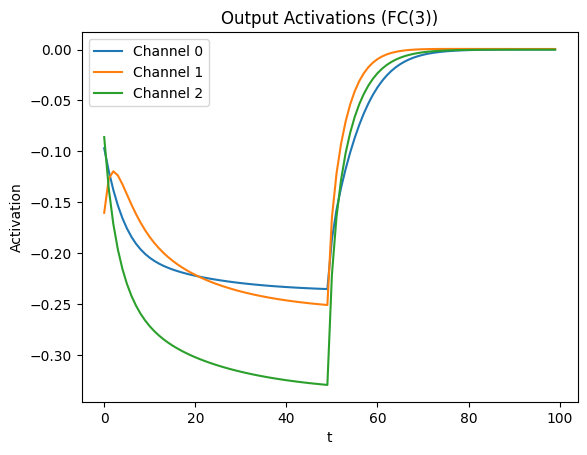

In [47]:
fig, ax = plt.subplots()
time = np.arange(100)
for output in range(3):
    ax.plot(time, out[0, :, output].cpu().detach().numpy(), label=f"Channel {output}")
ax.legend()
ax.set_xlabel('t')
ax.set_ylabel('Activation')
ax.set_title('Output Activations (FC(3))')
plt.show()

In [64]:
rnn_trainer.model.eval()
# Let's print an average of geodesic distances between network output and target, for a batch of 1000 random quaternions 
# where all some parts are negative. 
num = 1000
features = torch.zeros(num, seq_len, 8).to("cuda")
target = torch.zeros(num, 4).to("cuda")
for i in range(num):
    target[i] = (torch.rand(4).to("cuda") - 0.5) * 2
    target[i][0] = abs(target[i][0])
    target[i] = target[i]/torch.norm(target[i])
    for j in range(prep_phase):
        features[i, j, :] = torch.cat([target[i], -target[i]])

rnn_trainer.model(features)
pred = rnn_trainer.model.pred
g_loss = rnn_trainer.distance_loss(pred, target)
print(f"Average geodesic distance: {g_loss.mean()}")

Average geodesic distance: 2.4301459789276123


In [51]:
torch.cat([target, -target], dim = 1).shape

torch.Size([1000, 8])

# Experimentation with time losses. Sanity check and time complexity

## Sanity check first (what's the average geodesic distance from uniformly sampled quaternions?)

In [4]:
def random_quaternion(device):
    u = torch.rand(3, device=device)
    r = torch.sqrt(1 - u[0])
    phi = 2 * np.pi * u[1]
    theta = 2 * np.pi * u[2]

    x = r * torch.cos(phi)
    y = r * torch.sin(phi)
    z = torch.sqrt(u[0]) * torch.cos(theta)
    w = torch.sqrt(u[0]) * torch.sin(theta)
    
    if w < 0:
        w = -w
        x = -x
        y = -y
        z = -z

    return torch.stack((w, x, y, z))

def rand_quaternions(number, device = None):
    quat_list = [random_quaternion(device) for _ in range(number)]
    return torch.stack(quat_list, dim = 0)

In [22]:
# Implementation with my custom loss function. This should be in trainer.loss_fn

rand_quat = rand_quaternions(1000,"cuda")
target = torch.tensor([1, 0, 0, 0]).to("cuda")
target = target.unsqueeze(0).repeat(1000, 1)
start = time.time()
g_loss = rnn_trainer.distance_loss(rand_quat, target)
end = time.time()
print(f"Time taken: {end - start}")
rand_mat = quaternion_to_matrix(rand_quat)
target_mat = quaternion_to_matrix(target)
start = time.time()
g_loss2 = so3_relative_angle(rand_mat, target_mat)
end = time.time()
print(f"Time taken: {end - start}")

Time taken: 0.0
Time taken: 0.0020008087158203125


## Task 2: let's aim at speeding up my codes, by comparing my implementation of a forward loop and the one from the pytorch3d library.

In [28]:
rnn_trainer.model.eval()
out = rnn_trainer.model.out

In [29]:
dataloader = dataloaders[0][1]
features, label = next(iter(dataloader))

In [30]:
features = features.to("cuda:0")
start = time.time()
out = rnn_trainer.model(features)
end = time.time()
print(f"Time taken: {end - start}")

Time taken: 0.03299522399902344


In [31]:
rnn_trainer.model.pred[:, -1, :]

tensor([[ 0.1953,  0.4928,  0.1550,  0.8337],
        [ 0.2284,  0.1173,  0.1215,  0.9588],
        [ 0.2994,  0.0667,  0.4620,  0.8322],
        [ 0.4169,  0.0667,  0.7933,  0.4386],
        [ 0.5574,  0.1691,  0.6448,  0.4949],
        [ 0.0653,  0.3721,  0.8212,  0.4277],
        [ 0.2754,  0.7873,  0.5333,  0.1409],
        [ 0.4808,  0.0874,  0.4281,  0.7602],
        [ 0.5047,  0.5833,  0.4668,  0.4326],
        [ 0.5738,  0.3501,  0.6692,  0.3167],
        [ 0.3633,  0.2138,  0.6728,  0.6080],
        [ 0.1262,  0.9331,  0.1443,  0.3042],
        [ 0.5981,  0.5718,  0.4794,  0.2924],
        [ 0.6454,  0.2979,  0.5649,  0.4190],
        [ 0.4798,  0.6659,  0.2397,  0.5185],
        [ 0.4165,  0.3374,  0.4423,  0.7190],
        [ 0.5457,  0.0826,  0.5985,  0.5807],
        [ 0.5108,  0.6552,  0.2995,  0.4691],
        [ 0.5165,  0.3140,  0.5994,  0.5246],
        [ 0.7756,  0.4975,  0.0857,  0.3790],
        [ 0.4155,  0.3923,  0.4909,  0.6576],
        [ 0.3258,  0.2455,  0.1067